In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [3]:
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Class label']), df['Class label'], test_size=0.3, random_state=42)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() # range between only [0,1]

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [7]:
# Before Scaling X_train
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.3,1.6
50%,12.9,1.9
75%,13.7,3.2
max,14.8,5.8


In [8]:
# After Scaling X_train_scaled
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [9]:
# Bringing the entire data in a square of 1 sq-unit
# whose co-ordinates are (0,0), (0,1), (1,0) & (1,1)

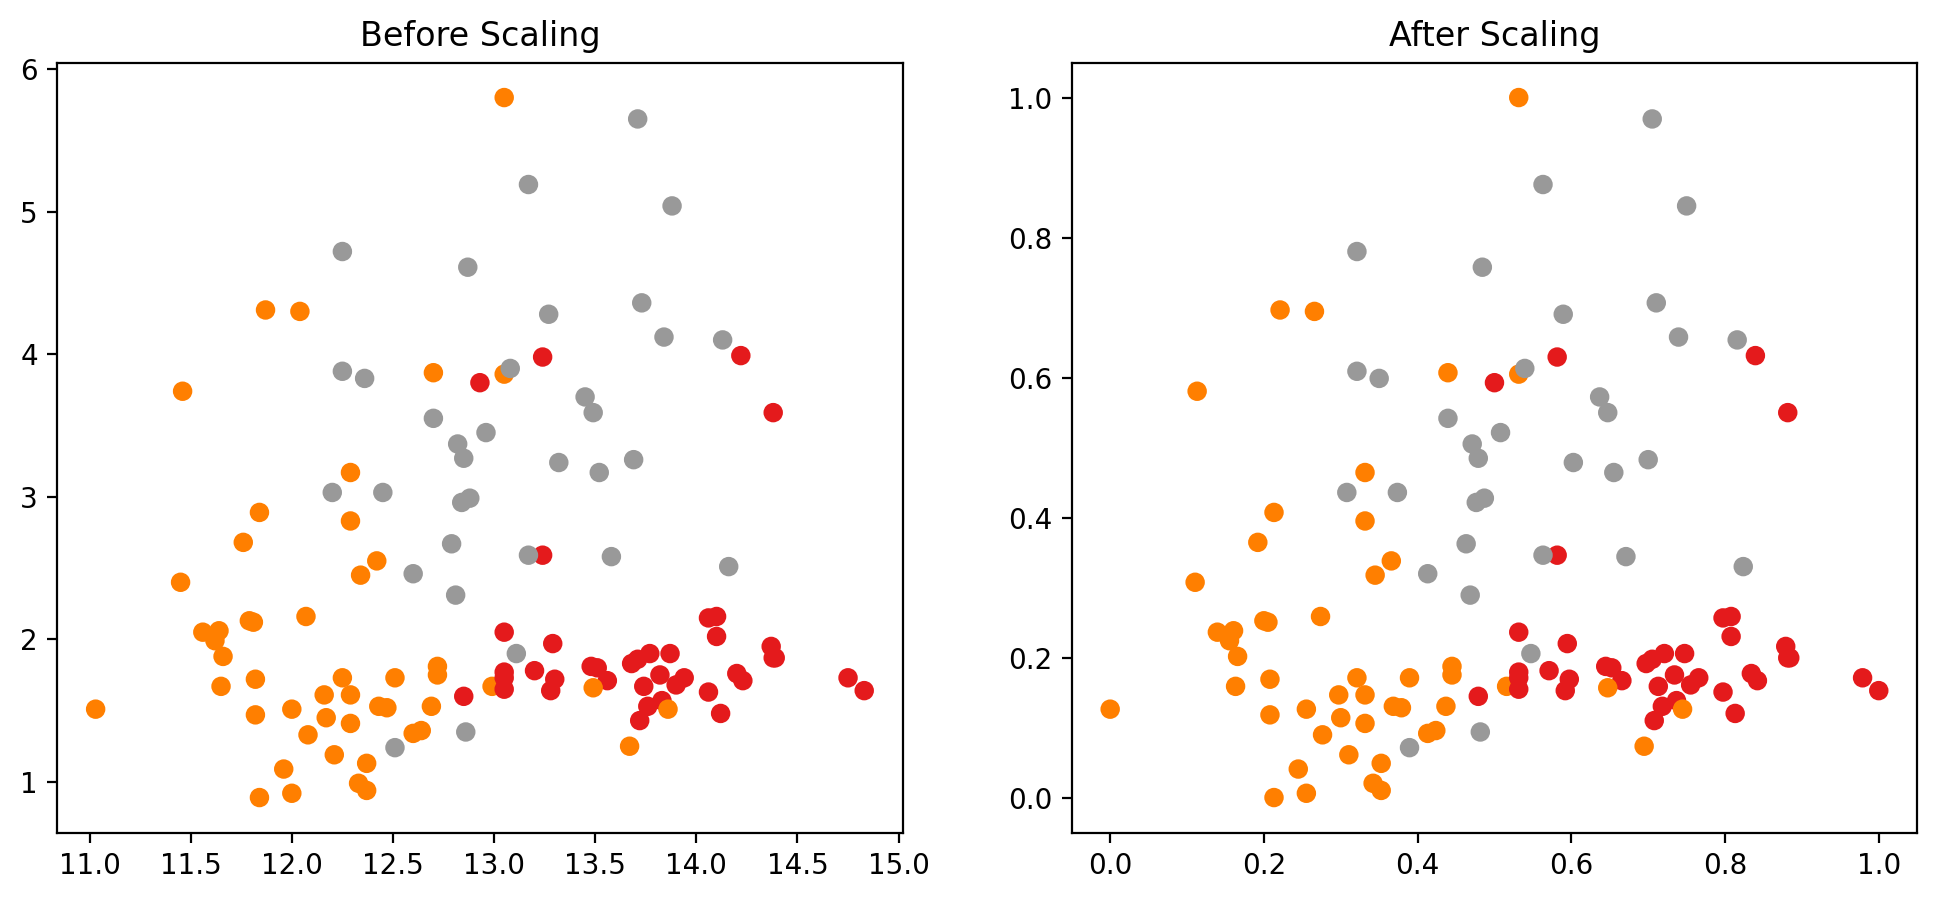

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), dpi=200)

# Before Scaling
ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train, cmap='Set1')
ax1.set_title("Before Scaling")

# After Scaling
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train, cmap='Set1')
ax2.set_title("After Scaling")

plt.show()